## Part 2: Discrete Quantum Information

Part 1 explored the time-dependent and time-independent Schrödinger equation 
for a single particle in continuous space. This section reframes the same 
core ideas, superposition, probability, measurement, in the discrete 
language of quantum circuits, setting up the direct comparison developed 
in Part 3.

The section covers four concepts, each mapped explicitly onto its Part 1 
counterpart:
- **Qubit as a truncated two-level system**, corresponding to the lowest 
  two levels (n=0, n=1) of the harmonic oscillator
- **Superposition**, corresponding to the wavepacket's own superposition 
  of momentum components
- **Measurement statistics**, the discrete Born rule, corresponding to 
  |ψ(x)|² as a continuous probability density
- **Entanglement**, which, as discussed at the end of this notebook, has 
  no single-particle analogue in Part 1

### A single, undisturbed qubit

A freshly initialised qubit should sit entirely in the ground state |0⟩, 
the discrete analogue of the harmonic oscillator naturally occupying its 
ground state ψ₀ until perturbed.

In [48]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

qc = QuantumCircuit(1)
state = Statevector(qc)
print(state)

Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


As expected, the state vector shows amplitude 1 on |0⟩ and 0 on |1⟩, 
confirming the qubit starts in a definite, unperturbed ground state.

### Creating superposition

Applying a Hadamard gate creates an equal-weight superposition, 
α = β = 1/√2, the qubit analogue of preparing a wavepacket with a 
specific spread of momentum components, rather than a single definite value.

In [49]:
qc = QuantumCircuit(1)
qc.h(0)

state = Statevector(qc)
print(state)

# Verify normalisation: |alpha|^2 + |beta|^2 should equal 1
probs = state.probabilities()
print("Probabilities:", probs)
print("Sum:", sum(probs))

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))
Probabilities: [0.5 0.5]
Sum: 0.9999999999999998


Both amplitudes come out equal (≈0.707), giving equal probabilities 
(0.5, 0.5) that sum to 1 within floating-point precision, the same 
normalisation check performed throughout Part 1, now applied to a 
two-level discrete system.

### Verifying superposition via measurement statistics

The Born rule predicts these probabilities should be reflected in actual 
measurement outcomes. Running 1000 shots tests this directly, mirroring 
the same predict-then-verify approach used for every result in Part 1.

Counts: {'1': 494, '0': 506}


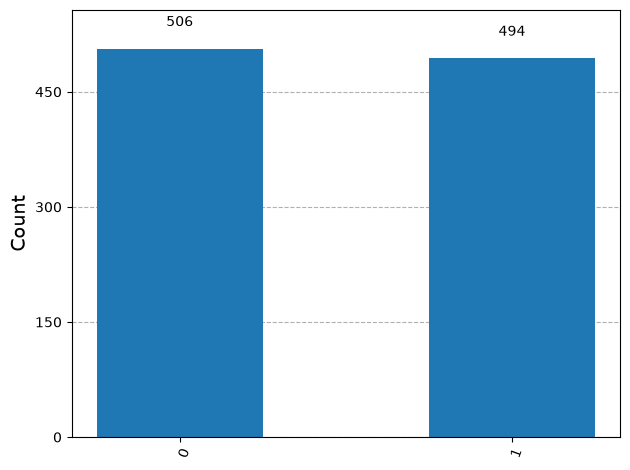

In [50]:
from qiskit_aer.primitives import SamplerV2 as Sampler
from qiskit.visualization import plot_histogram

qc_measured = qc.copy()
qc_measured.measure_all()

sampler = Sampler()
job = sampler.run([qc_measured], shots=1000)
result = job.result()
counts = result[0].data.meas.get_counts()

print("Counts:", counts)
plot_histogram(counts)

The measured counts split close to 500/500, with the small deviation 
expected from genuine statistical fluctuation, not error, confirming 
the predicted equal-probability superposition.

### Entanglement

Unlike the previous three concepts, entanglement has no single-particle 
counterpart in Part 1. It requires at least two subsystems whose combined 
state cannot be factored into independent single-particle states. The 
canonical example is the Bell state, built here using the same H + CX 
circuit as Part 2's very first Qiskit exercise.

In [51]:
qc_bell = QuantumCircuit(2)
qc_bell.h(0)
qc_bell.cx(0, 1)

state_bell = Statevector(qc_bell)
print(state_bell)

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


The state shows equal amplitude on |00⟩ and |11⟩, and exactly zero on 
|01⟩ and |10⟩, the numerical signature of perfect correlation between 
the two qubits.

Measurement statistics should confirm this: only |00⟩ and |11⟩ should 
ever appear, never the mixed outcomes.

In [52]:
qc_bell_measured = qc_bell.copy()
qc_bell_measured.measure_all()

job = sampler.run([qc_bell_measured], shots=1000)
result = job.result()
counts = result[0].data.meas.get_counts()
print("Counts:", counts)

Counts: {'00': 523, '11': 477}


Across 1000 shots, only |00⟩ and |11⟩ appear, confirming the correlation 
predicted by the state vector.

### Why entanglement has no Part 1 analogue

Unlike qubit states, superposition and measurement (all direct discrete 
analogues of Part 1's single-particle wave mechanics), entanglement 
requires ≥2 subsystems whose joint state cannot be factored into 
independent single-particle states. This can be proven explicitly for 
the Bell state: assuming separability leads to a direct algebraic 
contradiction. This is a genuine limitation of Part 1's scope, not an 
oversight, single-particle wavepacket dynamics simply cannot exhibit 
this phenomenon by construction.